# Phase 2: Building Machine Learning Models
## Linear Regression

In this notebook, we will train the Linear Regression first on our MinMax scaled data, and then completely separately on our Standard scaled data to compare the results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## Part 1: MinMax Scaled Dataset

### 1.1 Load the Data

In [2]:
data = pd.read_csv('Telco-Customer-Churn-MinMax.csv')
df = pd.DataFrame(data)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.013889,0,1,0.11,0.003339,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.472222,1,0,0.38,0.217526,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,0.027778,1,1,0.35,0.012437,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.625000,0,0,0.24,0.211884,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0.027778,1,1,0.52,0.017388,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,0.333333,1,1,0.66,0.229157,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,1.000000,1,1,0.85,0.847766,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,0.152778,0,1,0.11,0.039843,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,0.055556,1,1,0.56,0.035237,1,...,0,0,0,0,0,0,0,0,0,1


### 1.2 Train-Test Split (Data Segregation)
We split the data: $80\%$ for training, $20\%$ for testing. `random_state=42` ensures reproducible results.

In [3]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Size:", X_train.shape) 
print("Testing Data Size:", X_test.shape)

Training Data Size: (5634, 30)
Testing Data Size: (1409, 30)


### 1.3 Train the Model

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 1.4 Evaluate the Model

Accuracy Score: 0.8232789212207239

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.71      0.57      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.74      0.76      1409
weighted avg       0.82      0.82      0.82      1409



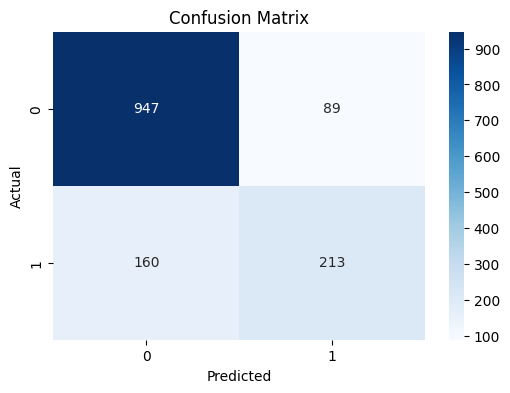

In [5]:
y_test_pred = model.predict(X_test)
y_test_pred = (y_test_pred > 0.5).astype(int)
print("Accuracy Score:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Part 2: Standard Scaled Dataset

### 2.1 Load the Data

In [6]:
data = pd.read_csv('Telco-Customer-Churn-Standard.csv')
df = pd.DataFrame(data)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.172988,-0.992780,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.066327,1,0,-0.275697,-0.172179,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,-1.236724,1,1,-0.375396,-0.957927,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,-0.740959,-0.193797,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,-1.236724,1,1,0.189564,-0.938956,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,-0.340876,1,1,0.654826,-0.127619,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,1.613701,1,1,1.286253,2.242419,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,-0.870241,0,1,-1.172988,-0.852925,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,-1.155283,1,1,0.322496,-0.870572,1,...,0,0,0,0,0,0,0,0,0,1


### 2.2 Train-Test Split (Data Segregation)

In [7]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Size:", X_train.shape) 
print("Testing Data Size:", X_test.shape)

Training Data Size: (5634, 30)
Testing Data Size: (1409, 30)


### 2.3 Train the Model

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 2.4 Evaluate the Model

Accuracy Score: 0.8232789212207239

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.71      0.57      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.74      0.76      1409
weighted avg       0.82      0.82      0.82      1409



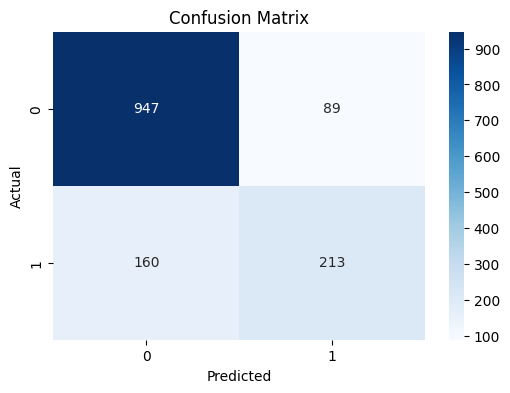

In [9]:
y_test_pred = model.predict(X_test)
y_test_pred = (y_test_pred > 0.5).astype(int)
print("Accuracy Score:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Part 3: Mathematical Theory & Explanations

### 📊 Model Deep Dive: Linear Regression

**What type of graph does it make?**
*   A straight, infinite mathematical line (or a hyperplane if there are multiple features). It tries to draw a line directly through the middle of the data points.

**When to use it?**
*   When you need to predict a **continuous number** (like Price, Temperature, or Age) and you believe the relationship between your data and the answer is linear (e.g., as house size goes up, price goes up proportionally).

**Why use it?**
*   It is incredibly fast, simple, and highly interpretable. You can look directly at the calculated weights ($\beta$) to see exactly how much one feature impacts the final prediction.


### Linear Regression for Classification
Traditionally, Linear Regression ($y = \beta_0 + \beta_1x_1 + \dots$) is used to predict continuous numbers (like Price or Temperature). To hack it into predicting categories (Churn vs No Churn), we set a hard threshold:
* If the raw prediction $\ge 0.5$, we classify it as $1$ (Churn).
* If the raw prediction $< 0.5$, we classify it as $0$ (No Churn).



## Part 4: The Fundamental Difference in Metrics
*   Use **Regression Metrics** (MAE, RMSE, $R^2$, Residuals) when your answer is a *continuous number* (Price: $\$250, \$599.99, \$10$). You measure the *distance* of the error.
*   Use **Classification Metrics** (Accuracy, Precision, Recall, Confusion Matrix) when your answer is a *strict category* (Churn: `Yes` or `No`). You measure the *count* of correct vs incorrect predictions. 

### Regression Metrics Explained (Predicting Continuous Numbers)
* **Mean Absolute Error (MAE):** The average absolute distance between the actual value and the predicted value. (e.g. "On average, our house price prediction was off by $\$5,000$").
* **Mean Squared Error (MSE):** The average of the *squared* distances. Squaring punishes the model heavily for making massive outliers/mistakes. 
* **Root Mean Squared Error (RMSE):** The square root of MSE. This brings the error back into the original units (e.g. "Dollars" instead of "Squared Dollars").
* **$R^2$ (R-Squared) Score:** This is the ultimate "goodness of fit" score. It tells us the percentage of the data's movement that is actually explained by our model.
  * $R^2 = 1 - \frac{Sum\ of\ Squared\ Residuals\ (SSR)}{Total\ Sum\ of\ Squares\ (SST)}$
  * **SSR (Sum of Squared Residuals):** The sum of the squared differences between the actual observed value ($y_i$) and the model's predicted value ($\hat{y}_i$). This measures the *unexplained* variance (the error of our line).
  * **SST (Total Sum of Squares):** The sum of the squared differences between the actual observed value ($y_i$) and the average/mean of all observed values ($\bar{y}$). This measures the *total variance* in the dataset (how spread out the data is from its own average).
* **Residuals:** The difference between the observed value and the predicted value. 
  $$Residual = y_i - \hat{y}_i$$

### Classification Metrics Explained (Predicting Strict Categories)
Because we are predicting strict categories (`1` or `0`), we use **Classification Metrics** to measure the *count* of correct vs. incorrect buckets.

**1. The Confusion Matrix**
The foundation of all classification metrics. It categorizes predictions into four absolute buckets:
* **True Positives (TP):** We predicted Churn ($1$), and they actually Churned ($1$).
* **True Negatives (TN):** We predicted No Churn ($0$), and they actually Didn't Churn ($0$).
* **False Positives (FP) [Type I Error]:** We predicted Churn ($1$), but they Didn't Churn ($0$). *(False Alarm)*
* **False Negatives (FN) [Type II Error]:** We predicted No Churn ($0$), but they actually Churned ($1$). *(Missed Opportunity)*

**2. Accuracy Score**
The percentage of total predictions the model got completely right.
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

**3. Precision (Quality of Positive Predictions)**
"Out of all the customers we *predicted* would churn, how many *actually* churned?"
$$Precision = \frac{TP}{TP + FP}$$

**4. Recall / Sensitivity (Quantity of Positive Predictions)**
"Out of all the customers who *actually* churned, how many did we successfully *find*?"
$$Recall = \frac{TP}{TP + FN}$$

**5. F1-Score**
The harmonic mean of Precision and Recall. It is the gold standard metric when your dataset is imbalanced.
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$
### 📉 Syllabus Additions: Linear Regression
**1. Linear Regression Assumptions:**
For the math $y = \beta_0 + \beta_1x_1$ to actually work properly, the algorithm assumes:
* **Linearity:** The relationship between features (X) and target (y) is actually a straight line.
* **Independence:** The observations (customers) don't affect each other.
* **Homoscedasticity:** The error (variance of residuals) is constant across all predictions.
* **Normality:** The errors (residuals) are normally distributed (bell curve).

**2. Limitations of Linear Regression:**
* It is extremely sensitive to outliers (which will wildly drag the straight line off course).
* It mathematically assumes a straight line. If the real-world data is curved (like our Churn probability), the straight line will completely fail to capture the true relationship.

### ⚖️ The Bias-Variance Tradeoff (Core ML Concept)
*   **Bias (Underfitting):** The model is too simple to capture the underlying pattern (e.g., trying to use a straight line on a curved dataset). High Bias = High Error on Training Data.
*   **Variance (Overfitting):** The model is so complex that it literally memorizes the training data completely, including the random noise. High Variance = Perfect score on Training Data, but terrible score on Unseen Test Data.
*   **The Tradeoff:** As you make a model more complex, Bias goes down but Variance goes up. The goal of Machine Learning is to find the perfect middle ground!

### 🔄 Cross-Validation (K-Fold)
Doing a simple 80/20 Train-Test split is risky. What if we accidentally put all the "easy" customers in the 20% test bucket by pure random chance? The Accuracy score would be artificially high!
*   **K-Fold Cross-Validation** solves this. We chop the dataset into $K$ equal buckets (e.g., 5 buckets). 
*   We train the model 5 separate times. Each time, we use 4 buckets to train, and a *different* bucket as the test set. 
*   We then average the 5 Accuracy scores together to get the true, undeniable performance of the model!


### 📈 Visualization: Plotting a Linear Regression Line

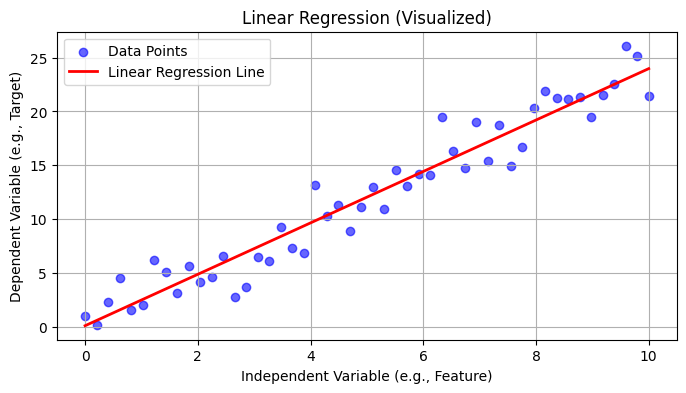

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a mock relationship for visualization
np.random.seed(42)
X_mock = np.linspace(0, 10, 50)
y_mock = 2.5 * X_mock + np.random.normal(0, 2, 50)

# Calculate the line of best fit (y = mx + b)
m, b = np.polyfit(X_mock, y_mock, 1)

plt.figure(figsize=(8, 4))
plt.scatter(X_mock, y_mock, color='blue', alpha=0.6, label='Data Points')
plt.plot(X_mock, m*X_mock + b, color='red', linewidth=2, label='Linear Regression Line')
plt.title("Linear Regression (Visualized)")
plt.xlabel("Independent Variable (e.g., Feature)")
plt.ylabel("Dependent Variable (e.g., Target)")
plt.legend()
plt.grid(True)
plt.show()